In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import confusion_matrix
from sklearn . metrics import ConfusionMatrixDisplay

In [ ]:
from sklearn.model_selection import train_test_split

data= pd.read_csv ( './data/Social_Network_Ads.csv'  )
data=data.drop("User ID",axis=1)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB
None


In [11]:
from sklearn.preprocessing import StandardScaler

data=pd.get_dummies(data, dtype=int)

X=data.drop(columns="Purchased")
y=data["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

continuous_cols = ['Age', 'EstimatedSalary']

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

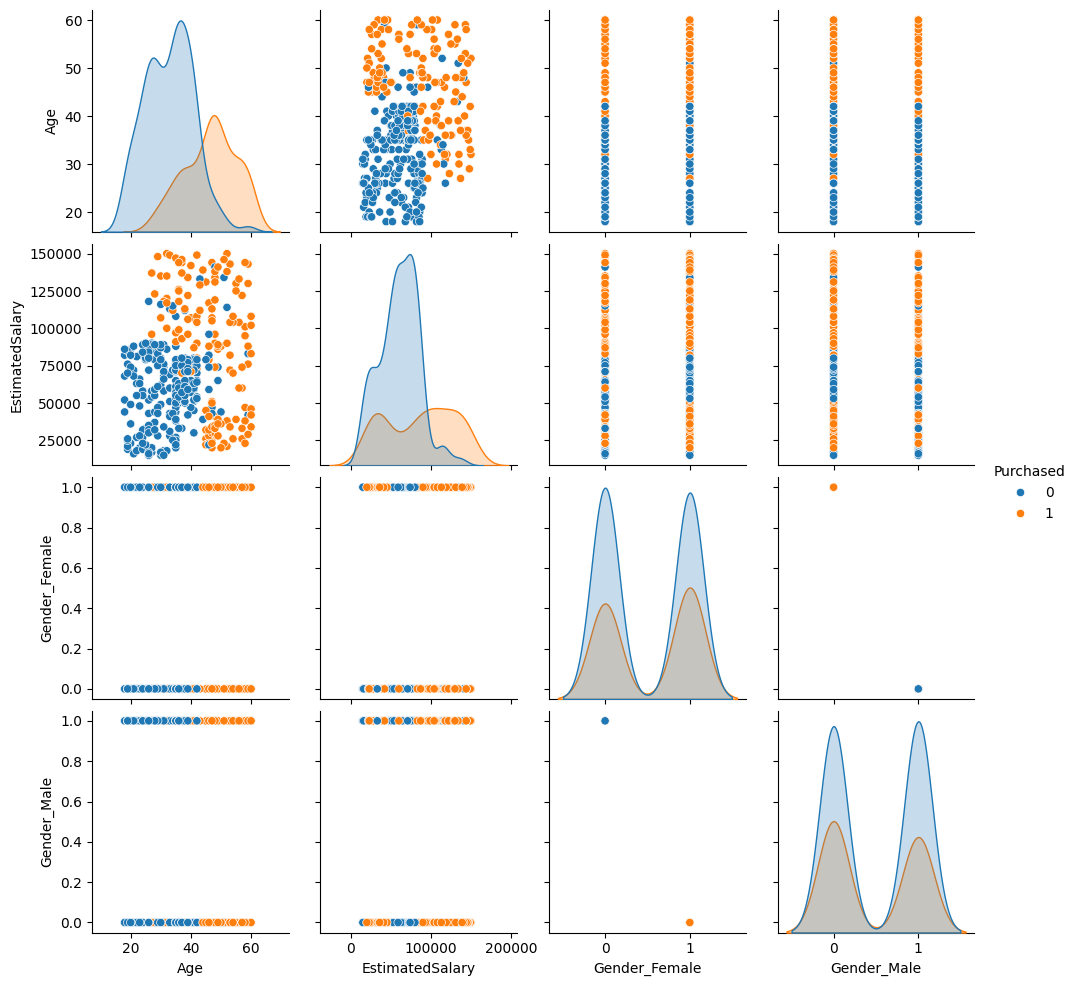

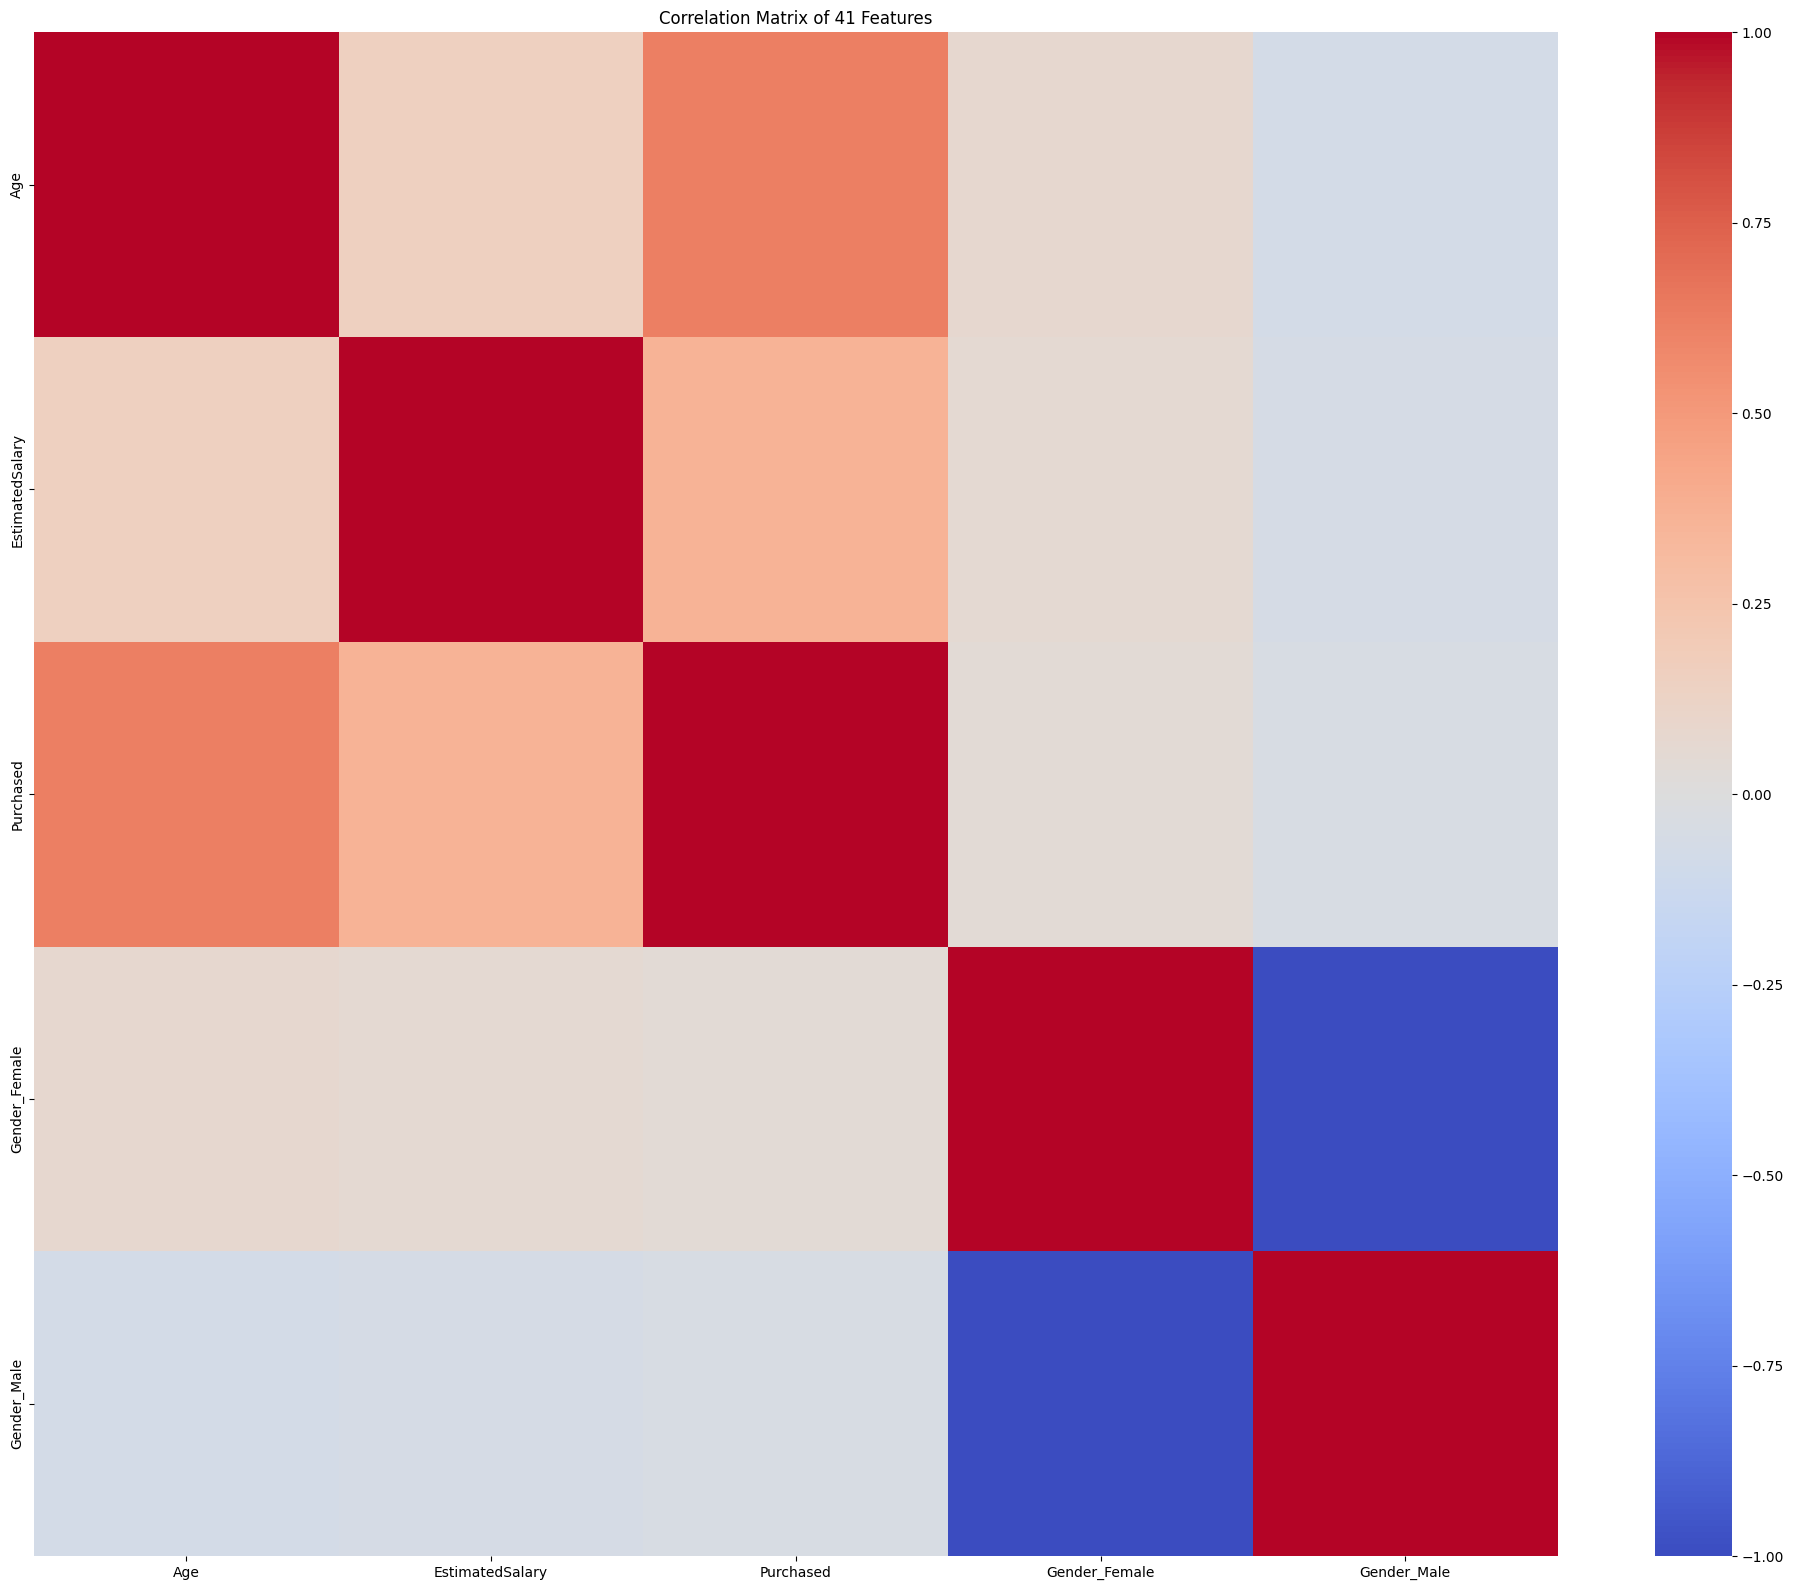

In [12]:
sns.pairplot(data, hue='Purchased')  
plt.show()

plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of 41 Features')
plt.tight_layout()
plt.show()

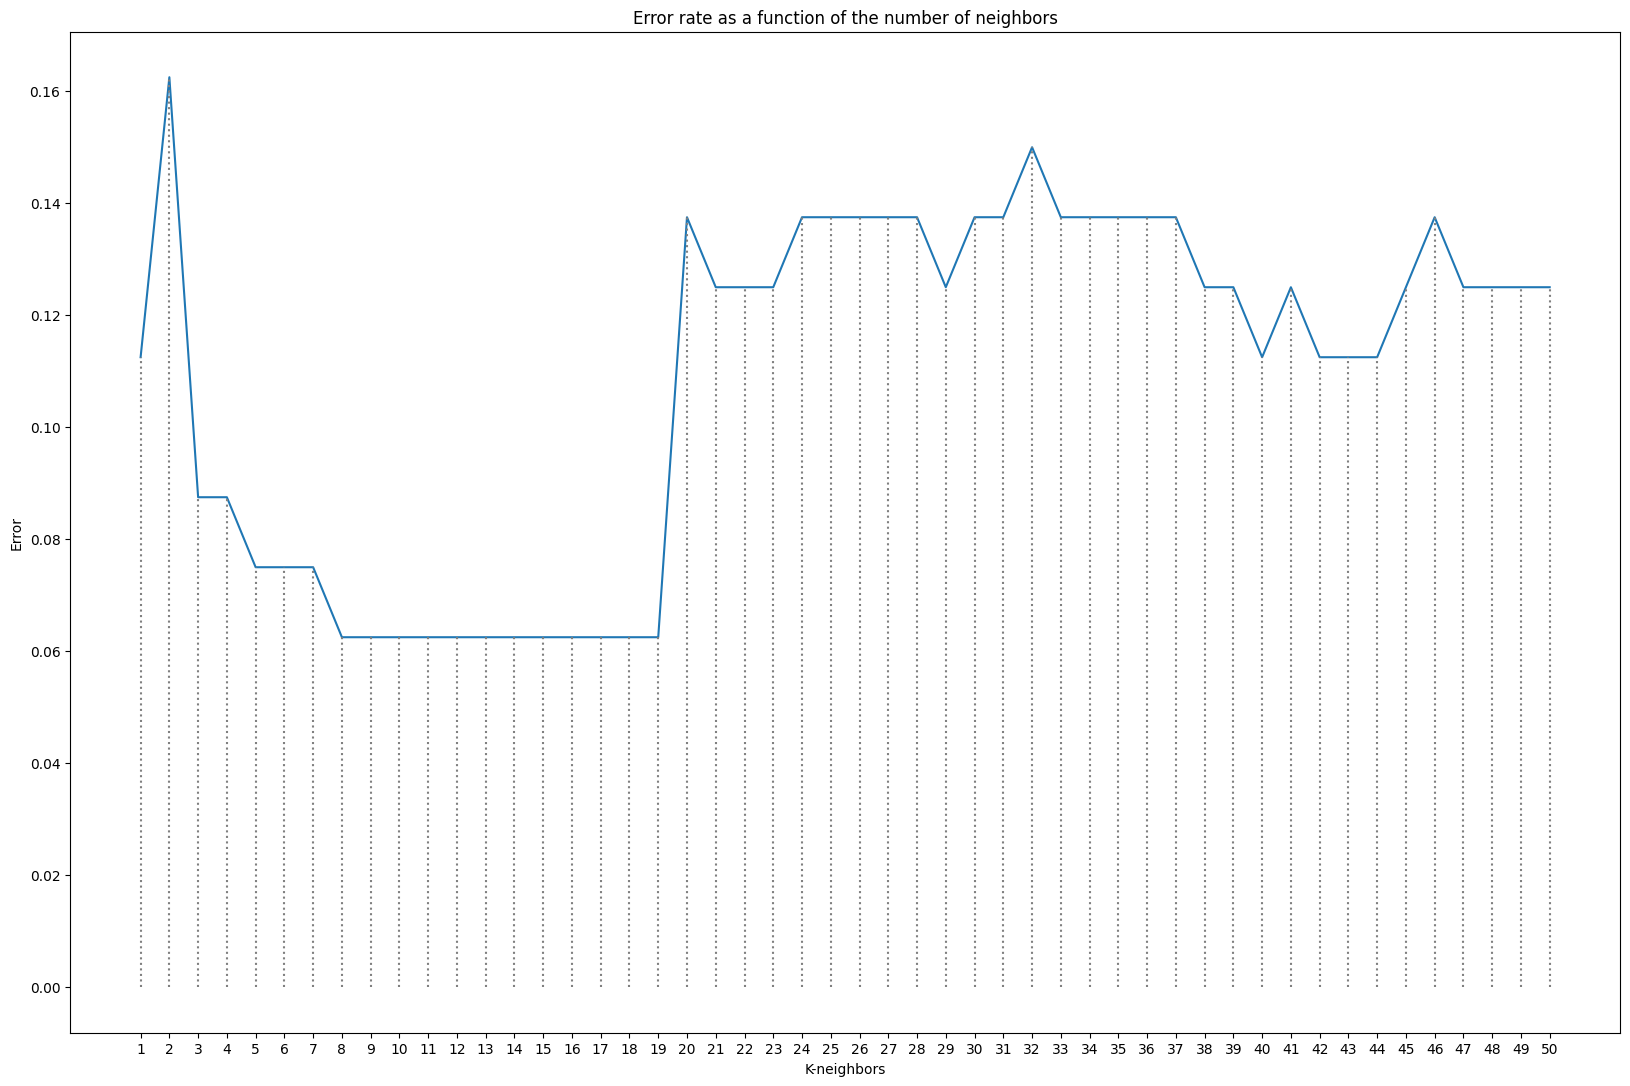

optimal k = 8
error = 0.062500


In [6]:
K=[0] * 50
optimal_k=0
optimal_error=1
for i,k in enumerate(K):
    knn = KNeighborsClassifier(n_neighbors=i+1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)
    if K[i]<optimal_error:
        optimal_error= K[i]
        optimal_k=i+1
    
plt.figure(figsize =(20,13))
plt.plot(np.arange(1,51,1), K)
plt.xticks(np.arange(1,51,1))
plt.vlines(np.arange(1,51,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("K-neighbors")
plt.ylabel("Error")
plt.title("Error rate as a function of the number of neighbors")
plt.show()

knn_error=K[optimal_k-1]

print("optimal k =",optimal_k)
print(f"error = {knn_error:.6f}" )

In [7]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred=gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

print(f"error = {gnb_error:.6f}" )

error = 0.075000


In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

lr . fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )

error = 0.112500


# Comparisons:


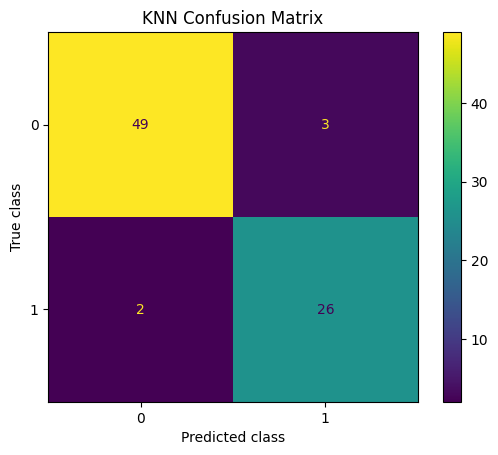

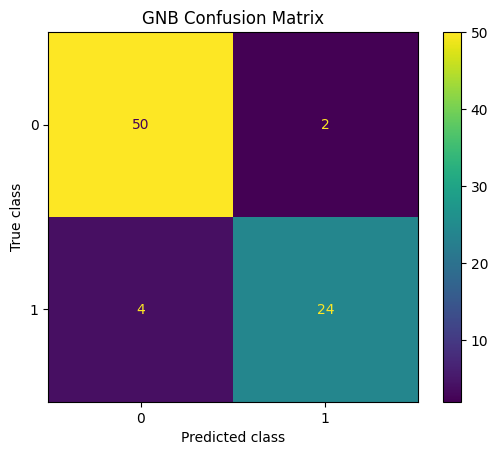

error = 0.112500


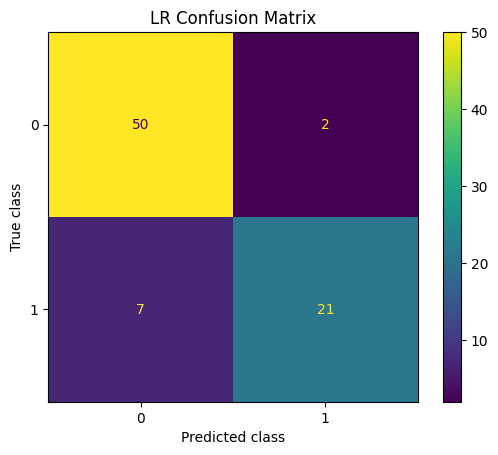

In [9]:
###################### Knn ######################

knn = KNeighborsClassifier(n_neighbors=optimal_k)

start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
training_duration_knn = end_time - start_time

start_time = time.time()
y_pred=knn.predict(X_test)
end_time = time.time()
prediction_time_knn = end_time - start_time
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm)
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("KNN Confusion Matrix")
plt .show()

###################### LR ######################

gnb = GaussianNB()

start_time = time.time()
gnb.fit(X_train, y_train)
end_time = time.time()
training_duration_gnb = end_time - start_time

start_time = time.time()
y_pred=gnb.predict(X_test)
end_time = time.time()
prediction_time_gnb = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("GNB Confusion Matrix")
plt .show()

###################### LR ######################

lr = LogisticRegression(random_state=42, max_iter=1000)

start_time = time.time()
lr . fit(X_train, y_train)
end_time = time.time()
training_duration_lr = end_time - start_time

start_time = time.time()
y_pred = lr.predict(X_test)
end_time = time.time()
prediction_time_lr = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )

cm = confusion_matrix(y_test, y_pred)
display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("LR Confusion Matrix")
plt .show()



In [10]:
print("Comparisons:")
print("-"*50)
print("Test set error :")
print(f"KNN: {knn_error:.4f}")
print(f"GNB: {gnb_error:.4f}")
print(f"LR: {lr_error:.4f}")
print("-"*50)
print("Training time :")
print(f"KNN: {training_duration_knn:.4f}")
print(f"GNB: {training_duration_gnb:.4f}")
print(f"LR: {training_duration_lr:.4f}")
print("-"*50)
print("Prediction time:")
print(f"KNN: {prediction_time_knn:.4f}")
print(f"GNB: {prediction_time_gnb:.4f}")
print(f"LR: {prediction_time_lr:.4f}")
print("-"*50)

Comparisons:
--------------------------------------------------
Test set error :
KNN: 0.0625
GNB: 0.0750
LR: 0.1125
--------------------------------------------------
Training time :
KNN: 0.0067
GNB: 0.0047
LR: 0.0120
--------------------------------------------------
Prediction time:
KNN: 0.0189
GNB: 0.0034
LR: 0.0027
--------------------------------------------------


## Conslusions:
- KNN performed best with the highest accuracy, suggesting the data has local, non-linear patterns well suited to its distance based approach. 
- Gaussian Naive Bayes was close in accuracy and much faster, indicating the naive independence assumption didn’t severely hurt performance here.
- Logistic Regression was the least accurate, implying the relationships between age, salary, and purchase aren’t effectively modeled by a linear boundary. 
- While KNN is ideal for maximizing accuracy when prediction speed isn’t critical, GNB offers the best balance of speed and performance for potential real time use. Overall, the dataset’s size and structure favor instance based or simple probabilistic models over linear ones.
